This notebook analyzes data organized by provider + drug

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re

In [2]:
import pandas as pd
from pathlib import Path
import re

data_dir = Path("..") / "data" / "raw" / "Medicare_Part_D_Prescribers_by_Provider_and_Drug"

# This grabs CSVs anywhere under that folder
files = sorted(data_dir.rglob("*.csv"))

len(files), [f.name for f in files[:6]]


(6,
 ['Medicare_Part_D_Prescribers_by_Provider_and_Drug_2018.csv',
  'Medicare_Part_D_Prescribers_by_Provider_and_Drug_2019.csv',
  'Medicare_Part_D_Prescribers_by_Provider_and_Drug_2020.csv',
  'Medicare_Part_D_Prescribers_by_Provider_and_Drug_2021.csv',
  'Medicare_Part_D_Prescribers_by_Provider_and_Drug_2022.csv',
  'Medicare_Part_D_Prescribers_by_Provider_and_Drug_2023.csv'])

First we will aggregate the data by state x year

In [5]:
data_dir = Path("..") / "data" / "raw" / "Medicare_Part_D_Prescribers_by_Provider_and_Drug"
files = sorted(data_dir.glob("*.csv"))

chunk_size = 300_000  # 300k is usually a good balance on Windows
agg_parts = []

usecols = [
    "Prscrbr_State_Abrvtn",
    "Tot_Clms",
    "Tot_30day_Fills",
    "Tot_Day_Suply",
    "Tot_Drug_Cst",
    "Tot_Benes",
    "GE65_Tot_Clms",
    "GE65_Tot_30day_Fills",
    "GE65_Tot_Day_Suply",
    "GE65_Tot_Drug_Cst",
]

num_cols = [c for c in usecols if c != "Prscrbr_State_Abrvtn"]

for f in files:
    m = re.search(r"(20\d{2})", f.name)
    if not m:
        print(f"⚠️ Skipping (no year found): {f.name}")
        continue
    year = int(m.group(1))
    print(f"Processing {f.name} | Year={year}")

    yearly_parts = []
    reader = None

    # Try UTF-8 first, then fall back
    for enc in ("utf-8", "latin-1"):
        try:
            reader = pd.read_csv(
                f,
                usecols=usecols,
                chunksize=chunk_size,
                encoding=enc,
                low_memory=False,
            )
            print(f"  Using encoding: {enc}")
            break
        except UnicodeDecodeError:
            continue

    if reader is None:
        raise RuntimeError(f"Could not decode file with utf-8 or latin-1: {f.name}")

    for chunk in reader:
        # convert numeric columns safely
        chunk[num_cols] = chunk[num_cols].apply(pd.to_numeric, errors="coerce")

        state_chunk = (
            chunk.groupby("Prscrbr_State_Abrvtn", dropna=False)[num_cols]
                 .sum()
                 .reset_index()
        )
        yearly_parts.append(state_chunk)

    state_year = (
        pd.concat(yearly_parts, ignore_index=True)
          .groupby("Prscrbr_State_Abrvtn", dropna=False)[num_cols]
          .sum()
          .reset_index()
    )
    state_year["Year"] = year
    agg_parts.append(state_year)

partd_state_year = pd.concat(agg_parts, ignore_index=True)
partd_state_year.head()

Processing Medicare_Part_D_Prescribers_by_Provider_and_Drug_2018.csv | Year=2018
  Using encoding: utf-8
Processing Medicare_Part_D_Prescribers_by_Provider_and_Drug_2019.csv | Year=2019
  Using encoding: utf-8
Processing Medicare_Part_D_Prescribers_by_Provider_and_Drug_2020.csv | Year=2020
  Using encoding: utf-8
Processing Medicare_Part_D_Prescribers_by_Provider_and_Drug_2021.csv | Year=2021
  Using encoding: utf-8
Processing Medicare_Part_D_Prescribers_by_Provider_and_Drug_2022.csv | Year=2022
  Using encoding: utf-8
Processing Medicare_Part_D_Prescribers_by_Provider_and_Drug_2023.csv | Year=2023
  Using encoding: utf-8


,Prscrbr_State_Abrvtn,Tot_Clms,Tot_30day_Fills,Tot_Day_Suply,Tot_Drug_Cst,Tot_Benes,GE65_Tot_Clms,GE65_Tot_30day_Fills,GE65_Tot_Day_Suply,GE65_Tot_Drug_Cst,Year
0,AA,1660,2196.9,53084,3.410478e+04,677.0,518.0,748.2,21256.0,7.966550e+03,2018
1,AE,17053,28267.4,755526,2.173455e+06,5858.0,6930.0,12049.7,336721.0,9.988712e+05,2018
2,AK,919370,1383484.3,35789213,8.595651e+07,126083.0,375841.0,608810.8,16197961.0,3.398980e+07,2018
3,AL,25180560,40863631.4,1141859178,2.369171e+09,6540640.0,13775472.0,23352239.9,660429785.0,1.065036e+09,2018
4,AP,11454,21026.2,562714,7.783034e+05,4485.0,5019.0,10651.8,301911.0,1.760076e+05,2018


In [6]:
out = Path("../data/processed/partd_state_year_2018_2023.parquet")
out.parent.mkdir(parents=True, exist_ok=True)

partd_state_year.to_parquet(out, index=False)
print("Saved:", out)

Saved: ..\data\processed\partd_state_year_2018_2023.parquet


In [7]:
print(partd_state_year.shape)
print(sorted(partd_state_year["Year"].unique()))

(368, 11)
[np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]


In [8]:
valid_states = [
    'AL','AK','AZ','AR','CA','CO','CT','DE','FL','GA','HI','ID','IL','IN','IA',
    'KS','KY','LA','ME','MD','MA','MI','MN','MS','MO','MT','NE','NV','NH','NJ',
    'NM','NY','NC','ND','OH','OK','OR','PA','RI','SC','SD','TN','TX','UT','VT',
    'VA','WA','WV','WI','WY','DC'
]

partd_state_year = partd_state_year[
    partd_state_year["Prscrbr_State_Abrvtn"].isin(valid_states)
]

partd_state_year.head()

,Prscrbr_State_Abrvtn,Tot_Clms,Tot_30day_Fills,Tot_Day_Suply,Tot_Drug_Cst,Tot_Benes,GE65_Tot_Clms,GE65_Tot_30day_Fills,GE65_Tot_Day_Suply,GE65_Tot_Drug_Cst,Year
2,AK,919370,1383484.3,35789213,8.595651e+07,126083.0,375841.0,608810.8,1.619796e+07,3.398980e+07,2018
3,AL,25180560,40863631.4,1141859178,2.369171e+09,6540640.0,13775472.0,23352239.9,6.604298e+08,1.065036e+09,2018
5,AR,16181550,23139096.8,650651566,1.197738e+09,3574695.0,8877815.0,13328834.6,3.809732e+08,5.382152e+08,2018
7,AZ,21419034,38457436.5,1092108654,2.171561e+09,5976649.0,10929182.0,20847066.8,6.035156e+08,1.064975e+09,2018
8,CA,119666870,205608693.3,5817155981,1.276714e+10,30112630.0,65160925.0,113518431.9,3.246517e+09,6.921546e+09,2018


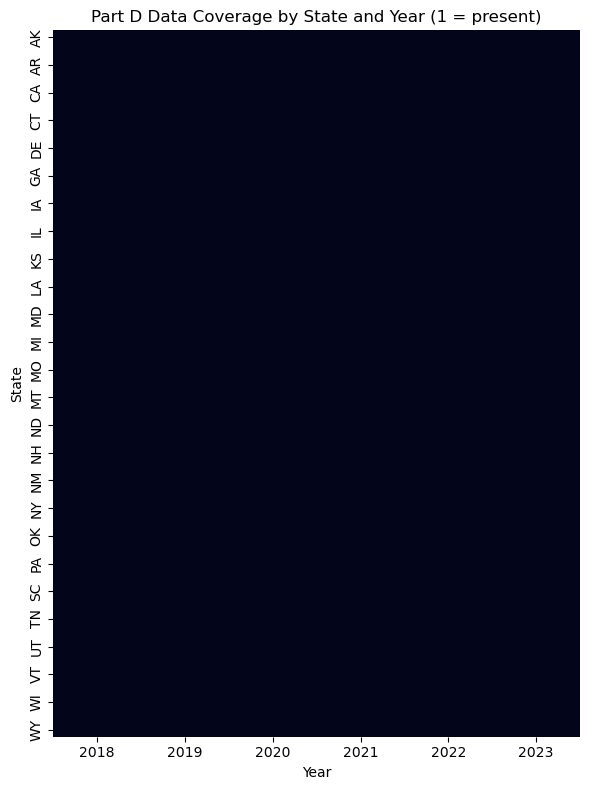

In [10]:

# 1 = state appears in that year
coverage = (partd_state_year
            .assign(present=1)
            .pivot_table(index="Prscrbr_State_Abrvtn", columns="Year", values="present", fill_value=0))

plt.figure(figsize=(6,8))
sns.heatmap(coverage.sort_index(), cbar=False)
plt.title("Part D Data Coverage by State and Year (1 = present)")
plt.xlabel("Year")
plt.ylabel("State")
plt.tight_layout()
plt.show()

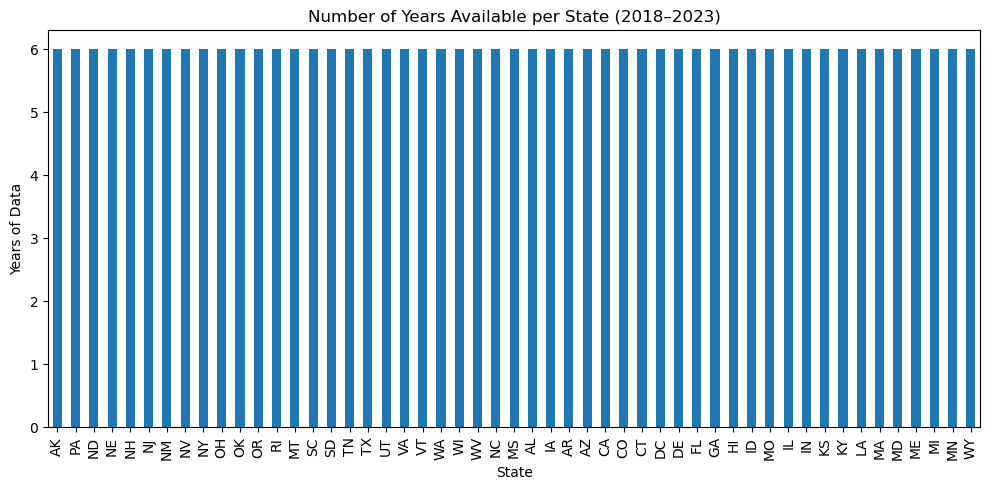

In [11]:
years_per_state = (partd_state_year.groupby("Prscrbr_State_Abrvtn")["Year"]
                   .nunique()
                   .sort_values(ascending=False))

plt.figure(figsize=(10,5))
years_per_state.plot(kind="bar")
plt.title("Number of Years Available per State (2018–2023)")
plt.xlabel("State")
plt.ylabel("Years of Data")
plt.tight_layout()
plt.show()

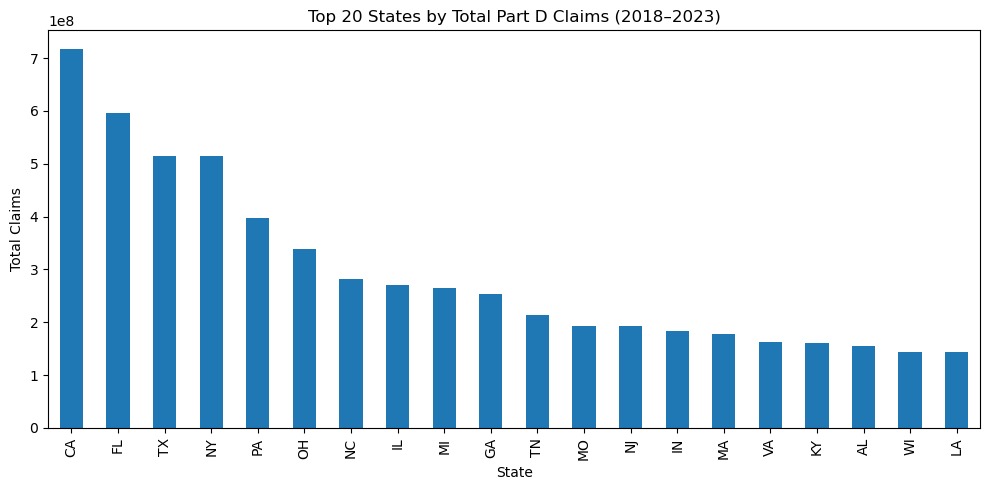

In [12]:
state_claims = (partd_state_year.groupby("Prscrbr_State_Abrvtn")["Tot_Clms"]
                .sum()
                .sort_values(ascending=False)
                .head(20))

plt.figure(figsize=(10,5))
state_claims.plot(kind="bar")
plt.title("Top 20 States by Total Part D Claims (2018–2023)")
plt.xlabel("State")
plt.ylabel("Total Claims")
plt.tight_layout()
plt.show()

In [13]:
all_states = partd_state_year["Prscrbr_State_Abrvtn"].dropna().unique()
all_years = partd_state_year["Year"].unique()

full_index = pd.MultiIndex.from_product([all_states, all_years],
                                        names=["Prscrbr_State_Abrvtn","Year"])

missing = (partd_state_year.set_index(["Prscrbr_State_Abrvtn","Year"])
           .reindex(full_index)
           .reset_index())

missing_state_years = missing[missing["Tot_Drug_Cst"].isna()][["Prscrbr_State_Abrvtn","Year"]]
missing_state_years

,Prscrbr_State_Abrvtn,Year


We can see from these plots that we have good coverage over the years 2018-2020.

Now let's combine the PROV dataset to get more information on provider type  

In [14]:
prov_dir = Path("..") / "data" / "raw" / "Medicare_Physician_Other_Practictioners_by_Provider"
prov_files = sorted(prov_dir.rglob("*.csv"))

len(prov_files), [f.name for f in prov_files[:6]]

(6,
 ['Medicare_Physician_Other_Practitioners_by_Provider_2018.csv',
  'Medicare_Physician_Other_Practitioners_by_Provider_2019.csv',
  'Medicare_Physician_Other_Practitioners_by_Provider_2020.csv',
  'Medicare_Physician_Other_Practitioners_by_Provider_2021.csv',
  'Medicare_Physician_Other_Practitioners_by_Provider_2022.csv',
  'Medicare_Physician_Other_Practitioners_by_Provider_2023.csv'])

In [22]:
import textwrap
prov_path = prov_files[-1]   
prov_path

prov_cols = pd.read_csv(prov_path, nrows=0).columns
print(textwrap.fill(", ".join(prov_cols), width=120))

Rndrng_NPI, Rndrng_Prvdr_Last_Org_Name, Rndrng_Prvdr_First_Name, Rndrng_Prvdr_MI, Rndrng_Prvdr_Crdntls,
Rndrng_Prvdr_Ent_Cd, Rndrng_Prvdr_St1, Rndrng_Prvdr_St2, Rndrng_Prvdr_City, Rndrng_Prvdr_State_Abrvtn,
Rndrng_Prvdr_State_FIPS, Rndrng_Prvdr_Zip5, Rndrng_Prvdr_RUCA, Rndrng_Prvdr_RUCA_Desc, Rndrng_Prvdr_Cntry,
Rndrng_Prvdr_Type, Rndrng_Prvdr_Mdcr_Prtcptg_Ind, Tot_HCPCS_Cds, Tot_Benes, Tot_Srvcs, Tot_Sbmtd_Chrg,
Tot_Mdcr_Alowd_Amt, Tot_Mdcr_Pymt_Amt, Tot_Mdcr_Stdzd_Amt, Drug_Sprsn_Ind, Drug_Tot_HCPCS_Cds, Drug_Tot_Benes,
Drug_Tot_Srvcs, Drug_Sbmtd_Chrg, Drug_Mdcr_Alowd_Amt, Drug_Mdcr_Pymt_Amt, Drug_Mdcr_Stdzd_Amt, Med_Sprsn_Ind,
Med_Tot_HCPCS_Cds, Med_Tot_Benes, Med_Tot_Srvcs, Med_Sbmtd_Chrg, Med_Mdcr_Alowd_Amt, Med_Mdcr_Pymt_Amt,
Med_Mdcr_Stdzd_Amt, Bene_Avg_Age, Bene_Age_LT_65_Cnt, Bene_Age_65_74_Cnt, Bene_Age_75_84_Cnt, Bene_Age_GT_84_Cnt,
Bene_Feml_Cnt, Bene_Male_Cnt, Bene_Race_Wht_Cnt, Bene_Race_Black_Cnt, Bene_Race_API_Cnt, Bene_Race_Hspnc_Cnt,
Bene_Race_NatInd_Cnt, Bene_Race_Ot

In [23]:
wanted = [
    "Rndrng_Prvdr_State_Abrvtn",
    "Rndrng_Prvdr_Type",
    "Tot_Benes",
    "Tot_Srvcs",
    "Tot_Sbmtd_Chrg",
    "Tot_Mdcr_Alowd_Amt",
    "Tot_Mdcr_Pymt_Amt",
]

[c for c in wanted if c in prov_cols]

['Rndrng_Prvdr_State_Abrvtn',
 'Rndrng_Prvdr_Type',
 'Tot_Benes',
 'Tot_Srvcs',
 'Tot_Sbmtd_Chrg',
 'Tot_Mdcr_Alowd_Amt',
 'Tot_Mdcr_Pymt_Amt']

In [24]:
prov_dir = Path("..") / "data" / "raw" / "Medicare_Physician_Other_Practictioners_by_Provider"
prov_files = sorted(prov_dir.rglob("*.csv"))

print("Found PROV files:", len(prov_files))
print([f.name for f in prov_files])

# --- Columns we actually need ---
usecols = [
    "Rndrng_Prvdr_State_Abrvtn",
    "Tot_Benes",
    "Tot_Srvcs",
    "Tot_Sbmtd_Chrg",
    "Tot_Mdcr_Alowd_Amt",
    "Tot_Mdcr_Pymt_Amt",
]

num_cols = [c for c in usecols if c != "Rndrng_Prvdr_State_Abrvtn"]

prov_parts = []

for f in prov_files:
    # Extract year from filename
    m = re.search(r"(20\d{2})", f.name)
    if not m:
        print(f"⚠️ Skipping (no year found): {f.name}")
        continue
    year = int(m.group(1))
    print(f"Processing {f.name} | Year={year}")

    # Handle encoding issues
    try:
        df = pd.read_csv(f, usecols=usecols, encoding="utf-8", on_bad_lines="skip")
    except UnicodeDecodeError:
        df = pd.read_csv(f, usecols=usecols, encoding="latin-1", on_bad_lines="skip")

    # Convert numeric columns
    df[num_cols] = df[num_cols].apply(pd.to_numeric, errors="coerce")

    # Aggregate to State level
    state_year = (
        df.groupby("Rndrng_Prvdr_State_Abrvtn", dropna=False)
          .agg(
              prov_tot_benes=("Tot_Benes", "sum"),
              prov_tot_srvcs=("Tot_Srvcs", "sum"),
              prov_tot_submitted=("Tot_Sbmtd_Chrg", "sum"),
              prov_tot_allowed=("Tot_Mdcr_Alowd_Amt", "sum"),
              prov_tot_payment=("Tot_Mdcr_Pymt_Amt", "sum"),
          )
          .reset_index()
    )

    state_year["Year"] = year
    prov_parts.append(state_year)

    del df  # free memory

# Combine all years
prov_state_year = pd.concat(prov_parts, ignore_index=True)

# Derived metric
prov_state_year["prov_payment_per_service"] = (
    prov_state_year["prov_tot_payment"] /
    prov_state_year["prov_tot_srvcs"].replace(0, pd.NA)
)

print("Built prov_state_year:", prov_state_year.shape)
prov_state_year.head()

Found PROV files: 6
['Medicare_Physician_Other_Practitioners_by_Provider_2018.csv', 'Medicare_Physician_Other_Practitioners_by_Provider_2019.csv', 'Medicare_Physician_Other_Practitioners_by_Provider_2020.csv', 'Medicare_Physician_Other_Practitioners_by_Provider_2021.csv', 'Medicare_Physician_Other_Practitioners_by_Provider_2022.csv', 'Medicare_Physician_Other_Practitioners_by_Provider_2023.csv']
Processing Medicare_Physician_Other_Practitioners_by_Provider_2018.csv | Year=2018
Processing Medicare_Physician_Other_Practitioners_by_Provider_2019.csv | Year=2019
Processing Medicare_Physician_Other_Practitioners_by_Provider_2020.csv | Year=2020
Processing Medicare_Physician_Other_Practitioners_by_Provider_2021.csv | Year=2021
Processing Medicare_Physician_Other_Practitioners_by_Provider_2022.csv | Year=2022
Processing Medicare_Physician_Other_Practitioners_by_Provider_2023.csv | Year=2023
Built prov_state_year: (369, 8)


,Rndrng_Prvdr_State_Abrvtn,prov_tot_benes,prov_tot_srvcs,prov_tot_submitted,prov_tot_allowed,prov_tot_payment,Year,prov_payment_per_service
0,AA,6834,14175.0,3.215029e+06,5.686324e+05,4.438615e+05,2018,31.312982
1,AE,9875,36516.0,9.088107e+06,2.412801e+06,1.841569e+06,2018,50.431849
2,AK,567959,4671606.1,1.038107e+09,2.379405e+08,1.835998e+08,2018,39.301221
3,AL,6574750,63854987.5,6.449526e+09,2.169305e+09,1.702332e+09,2018,26.659344
4,AP,8224,17716.0,9.247916e+06,1.766193e+06,1.362231e+06,2018,76.892690


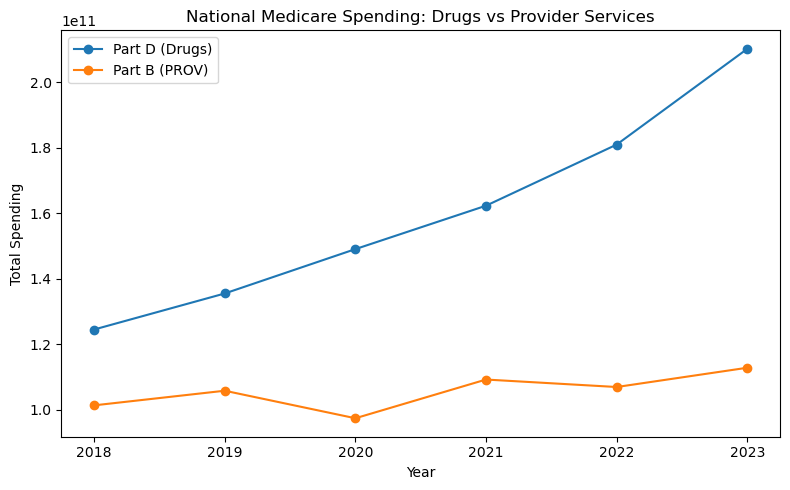

In [25]:

# National totals
national_drug = (
    partd_state_year.groupby("Year")["Tot_Drug_Cst"]
    .sum()
    .sort_index()
)

national_prov = (
    prov_state_year.groupby("Year")["prov_tot_payment"]
    .sum()
    .sort_index()
)

plt.figure(figsize=(8,5))
plt.plot(national_drug.index, national_drug.values, marker="o", label="Part D (Drugs)")
plt.plot(national_prov.index, national_prov.values, marker="o", label="Part B (PROV)")
plt.title("National Medicare Spending: Drugs vs Provider Services")
plt.xlabel("Year")
plt.ylabel("Total Spending")
plt.legend()
plt.tight_layout()
plt.show()

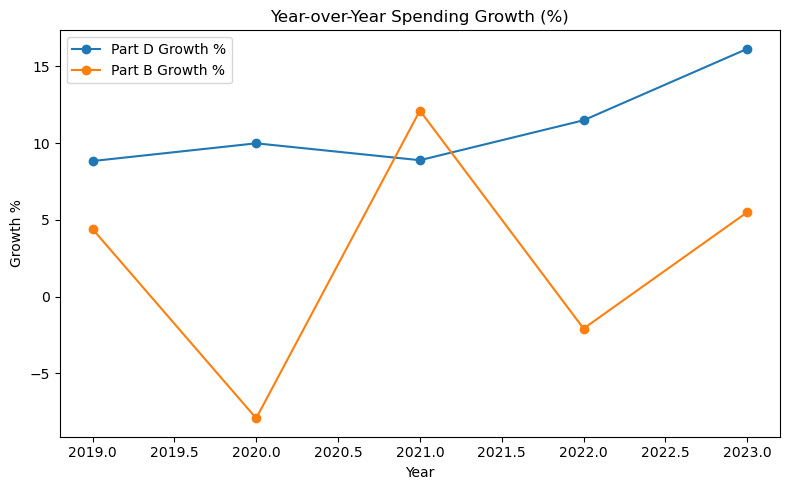

In [26]:
drug_growth = national_drug.pct_change() * 100
prov_growth = national_prov.pct_change() * 100

plt.figure(figsize=(8,5))
plt.plot(drug_growth.index, drug_growth.values, marker="o", label="Part D Growth %")
plt.plot(prov_growth.index, prov_growth.values, marker="o", label="Part B Growth %")
plt.title("Year-over-Year Spending Growth (%)")
plt.xlabel("Year")
plt.ylabel("Growth %")
plt.legend()
plt.tight_layout()
plt.show()

Now let's combien data with Medicare part D

In [27]:
combined = partd_state_year.merge(
    prov_state_year,
    left_on=["Prscrbr_State_Abrvtn","Year"],
    right_on=["Rndrng_Prvdr_State_Abrvtn","Year"],
    how="inner"
)

combined["total_spending"] = (
    combined["Tot_Drug_Cst"] + combined["prov_tot_payment"]
)

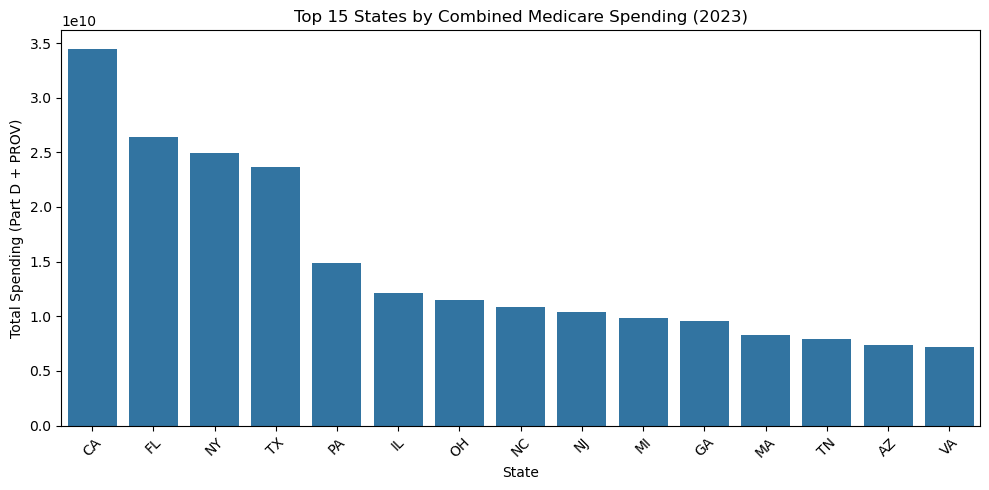

In [28]:

combined_2023 = (
    combined[combined["Year"]==2023]
    .sort_values("total_spending", ascending=False)
    .head(15)
)

plt.figure(figsize=(10,5))
sns.barplot(
    data=combined_2023,
    x="Prscrbr_State_Abrvtn",
    y="total_spending"
)
plt.title("Top 15 States by Combined Medicare Spending (2023)")
plt.xlabel("State")
plt.ylabel("Total Spending (Part D + PROV)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\alybo\AppData\Local\Temp\ipykernel_25340\1867382636.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g["prov_tot_payment"].sum() / g["prov_tot_srvcs"].sum())


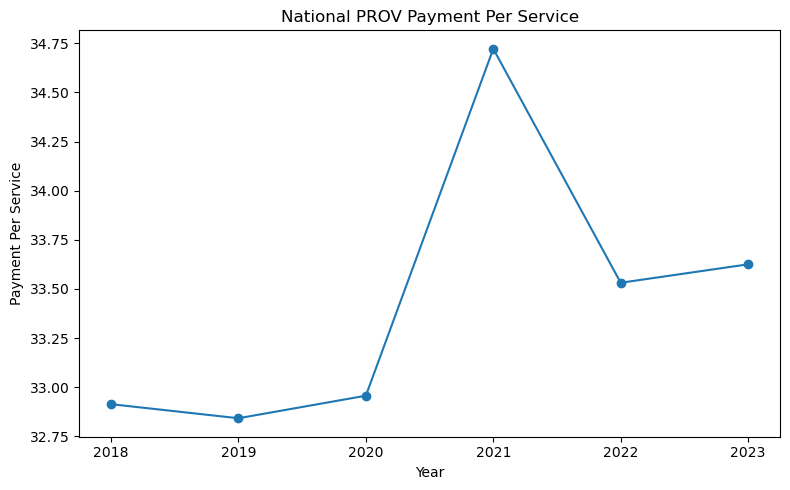

In [29]:
nat_pps = (
    prov_state_year.groupby("Year")
    .apply(lambda g: g["prov_tot_payment"].sum() / g["prov_tot_srvcs"].sum())
    .sort_index()
)

plt.figure(figsize=(8,5))
plt.plot(nat_pps.index, nat_pps.values, marker="o")
plt.title("National PROV Payment Per Service")
plt.xlabel("Year")
plt.ylabel("Payment Per Service")
plt.tight_layout()
plt.show()

C:\Users\alybo\AppData\Local\Temp\ipykernel_25340\1660934930.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g["Tot_Drug_Cst"].sum() / g["Tot_Clms"].sum())


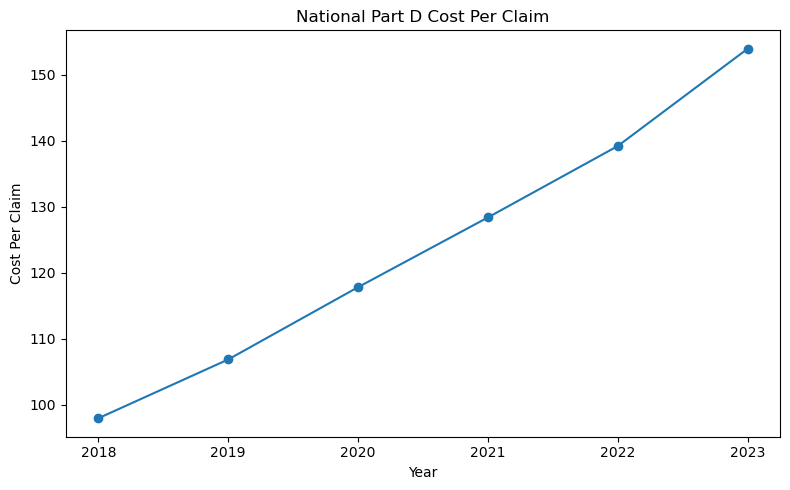

In [30]:
nat_cost_per_claim = (
    partd_state_year.groupby("Year")
    .apply(lambda g: g["Tot_Drug_Cst"].sum() / g["Tot_Clms"].sum())
    .sort_index()
)

plt.figure(figsize=(8,5))
plt.plot(nat_cost_per_claim.index, nat_cost_per_claim.values, marker="o")
plt.title("National Part D Cost Per Claim")
plt.xlabel("Year")
plt.ylabel("Cost Per Claim")
plt.tight_layout()
plt.show()